In [8]:
%pip install --user --upgrade numpy scipy

     |████████████████████████████████| 19.5 MB 11.4 MB/s            
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway
from matplotlib import pyplot as plt


files = {
    # ramses2007- no aslr, boosting enabled, sleep 3s between runs
    "b1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b1.csv",
    "b2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b2.csv",
    "b3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b3.csv",
    "b4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b4.csv",
    "b5": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b5.csv",
    "b6": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b6.csv",
    "b7": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b7.csv",
    "b8": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b8.csv",
    "b9": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/b9.csv",
    # ramses2004 - no aslr, boosting enabled, sleep 3s between runs
    "bs1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bs1.csv",
    "bs2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bs2.csv",
    "bs3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bs3.csv",
    "bs4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bs4.csv",
    "bs5": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bs5.csv",
    #ramses2004 - aslr enabled, boosting enabled, sleep 3s between runs
    "bsa1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bsa1.csv",
    "bsa2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bsa2.csv",
    "bsa3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bsa3.csv",
    "bsa4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bsa4.csv",
    "bsa5": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/bsa5.csv",
}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[df['Type'] == 'ITER']
df_io=df[df['Type'] == 'IO_LOAD']

Number of runs per environment: {'b1': 20, 'b2': 20, 'b3': 20, 'b4': 20, 'b5': 20, 'b6': 12, 'b7': 20, 'b8': 20, 'b9': 20, 'bs1': 20, 'bs2': 20, 'bs3': 20, 'bs4': 20, 'bs5': 20, 'bsa1': 20, 'bsa2': 20, 'bsa3': 20}


/tmp/ipykernel_2216380/2917061276.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")


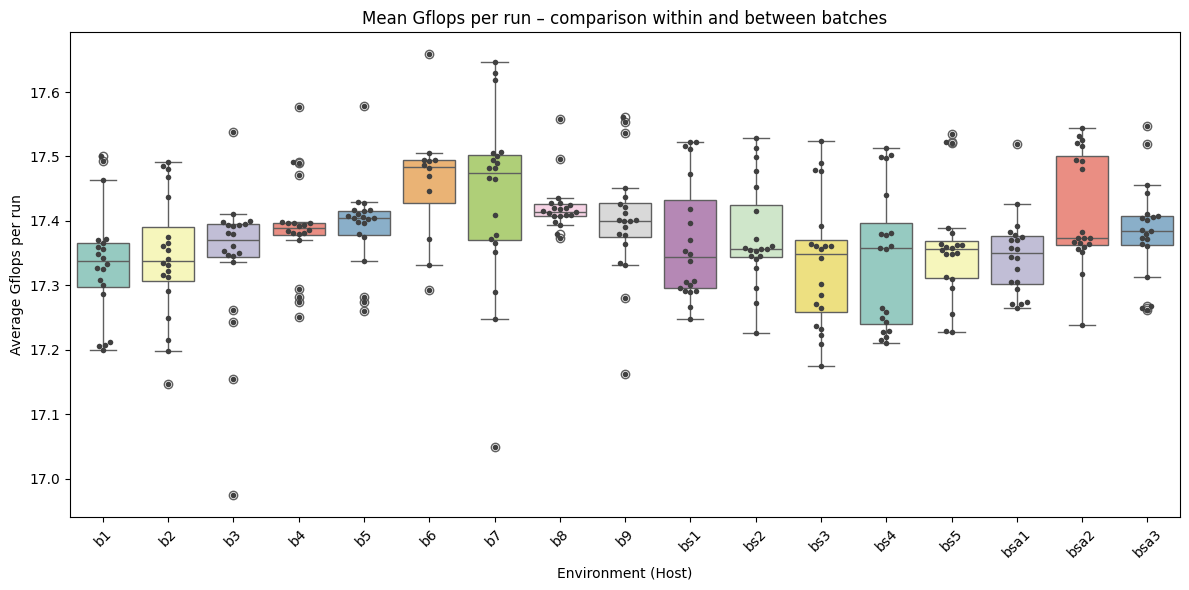


=== VARIANCES ===
Average variance WITHIN a file (run-to-run): 0.0083
Variance BETWEEN files (host means):         0.0015
Ratio (between / within):                    0.18

=== ANOVA RESULTS ===
F-statistic:      3.2221
p-value:          0.000036
→ SIGNIFICANT difference between hosts (p < 0.05)!
   The runs within a file are strongly correlated.
   You should consider the environment (host) as a factor.

Intra-Class Correlation (ICC): 0.0844  (the higher, the stronger runs within a file are correlated)


In [26]:
run_means = (
    df_iter
    .groupby(['Environment', 'Run'])['Gflops']
    .mean()
    .reset_index(name='mean_Gflops')
)

print("Number of runs per environment:", run_means.groupby('Environment')['Run'].count().to_dict())

plt.figure(figsize=(12, 6))
sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")
sns.swarmplot(x='Environment', y='mean_Gflops', data=run_means, color=".25", size=4)
plt.title('Mean Gflops per run – comparison within and between batches')
plt.xlabel('Environment (Host)')
plt.ylabel('Average Gflops per run')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

groups = []
env_means = []
within_vars = []

for env, group in run_means.groupby('Environment'):
    run_values = group['mean_Gflops'].values
    groups.append(run_values)
    env_means.append(np.mean(run_values))
    within_vars.append(np.var(run_values, ddof=1)) 

avg_within_variance = np.mean(within_vars)         
between_variance = np.var(env_means, ddof=1)        

print("\n=== VARIANCES ===")
print(f"Average variance WITHIN a file (run-to-run): {avg_within_variance:.4f}")
print(f"Variance BETWEEN files (host means):         {between_variance:.4f}")
print(f"Ratio (between / within):                    {between_variance / avg_within_variance:.2f}")

f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA RESULTS ===")
print(f"F-statistic:      {f_stat:.4f}")
print(f"p-value:          {p_value:.6f}")

if p_value < 0.05:
    print("→ SIGNIFICANT difference between hosts (p < 0.05)!")
    print("   The runs within a file are strongly correlated.")
    print("   You should consider the environment (host) as a factor.")
else:
    print("→ NO significant difference between hosts (p >= 0.05).")
    print("   Runs can be considered individually – independent of the file.")

grand_mean = np.mean(env_means)
ss_between = 10 * np.sum((np.array(env_means) - grand_mean)**2)  #Runs per host
ss_within = sum(np.sum((g - np.mean(g))**2) for g in groups)
icc = ss_between / (ss_between + ss_within)
print(f"\nIntra-Class Correlation (ICC): {icc:.4f}  (the higher, the stronger runs within a file are correlated)")

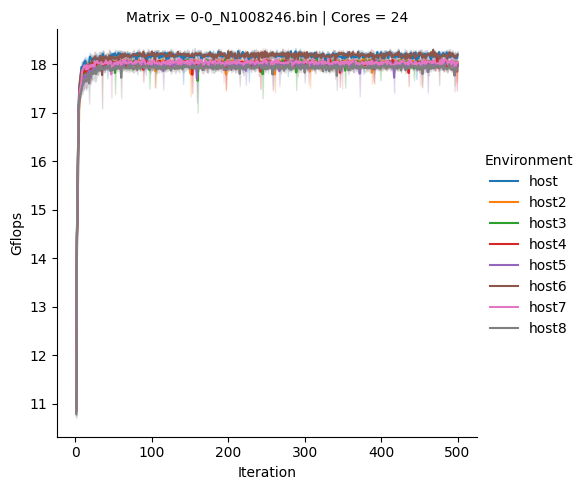

In [15]:
g = sns.relplot(
    data=df_iter, 
    x='Iteration', 
    y='Gflops', 
    hue='Environment',     
    col='Cores',      
	row='Matrix',       
    kind='line', 
    facet_kws={'sharey': False}, 
)

in jedem host run -> 5 runs , darin pro iter den std nehmen

In [25]:
for file in files.keys():
	df_single = df_iter[df_iter['Environment'] == file]
	df_std = df_single.groupby(['Matrix', 'Cores','Iteration'])['Gflops'].std().reset_index(name='Gflops_std')
	mean = df_std["Gflops_std"].mean()
	print(f"{file}: {mean}")


host1: 0.08363225254627313
host2: 0.08001127720328481
host3: 0.08064715701800575
host4: 0.0785511465783191
host5: 0.0790866060978347
host6: 0.08532432040077996
host7: 0.08065619325027629
host8: 0.07701019726611377
